In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split, GridSearchCV,KFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix


### **Keplar data**

In [121]:
keplar_df = pd.read_csv("keplar_data.csv", comment="#")
keplar_df

,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,10811496,K00753.01,NaN,CANDIDATE,CANDIDATE,0.000,0,0,0,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,10090151,K07985.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,0,...,-166.0,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082
9560,10128825,K07986.01,NaN,CANDIDATE,CANDIDATE,0.497,0,0,0,0,...,-220.0,4.444,0.056,-0.224,1.031,0.341,-0.114,286.50937,47.163219,14.757
9561,10147276,K07987.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.021,0,0,1,0,...,-236.0,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385
9562,10155286,K07988.01,NaN,CANDIDATE,CANDIDATE,0.092,0,0,0,0,...,-128.0,2.992,0.030,-0.027,7.824,0.223,-1.896,296.76288,47.145142,10.998


In [122]:
keplar_df.describe()

,kepid,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
count,9.564000e+03,8054.000000,9564.000000,9564.000000,9564.000000,9564.000000,9564.000000,9110.000000,9110.000000,9564.000000,...,9081.000000,9201.000000,9096.000000,9096.000000,9201.000000,9096.000000,9096.000000,9564.000000,9564.000000,9563.000000
mean,7.690628e+06,0.480829,0.208595,0.232748,0.197512,0.120033,75.671358,0.002148,-0.002148,166.183251,...,-162.265059,4.310157,0.120738,-0.143161,1.728712,0.362292,-0.394806,292.060163,43.810433,14.264606
std,2.653459e+06,0.476928,4.767290,0.422605,0.398142,0.325018,1334.744046,0.008236,0.008236,67.918960,...,72.746348,0.432606,0.132837,0.085477,6.127185,0.930870,2.168213,4.766657,3.601243,1.385448
min,7.574500e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.241843,0.000000,-0.172500,120.515914,...,-1762.000000,0.047000,0.000000,-1.207000,0.109000,0.000000,-116.137000,279.852720,36.577381,6.966000
25%,5.556034e+06,0.000000,0.000000,0.000000,0.000000,0.000000,2.733684,0.000005,-0.000276,132.761718,...,-198.000000,4.218000,0.042000,-0.196000,0.829000,0.129000,-0.250000,288.660770,40.777173,13.440000
50%,7.906892e+06,0.334000,0.000000,0.000000,0.000000,0.000000,9.752831,0.000035,-0.000035,137.224595,...,-160.000000,4.438000,0.070000,-0.128000,1.000000,0.251000,-0.111000,292.261125,43.677504,14.520000
75%,9.873066e+06,0.998000,0.000000,0.000000,0.000000,0.000000,40.715178,0.000276,-0.000005,170.694603,...,-114.000000,4.543000,0.149000,-0.088000,1.345000,0.364000,-0.069000,295.859160,46.714611,15.322000
max,1.293514e+07,1.000000,465.000000,1.000000,1.000000,1.000000,129995.778400,0.172500,0.000000,1472.522306,...,0.000000,5.364000,1.472000,0.000000,229.908000,33.091000,0.000000,301.720760,52.336010,20.003000


In [123]:
null_counts = keplar_df.isnull().sum()
print("Null counts for each column:\n", null_counts)

print("\nNull counts and the columns with those counts:")
for count in sorted(null_counts.unique()):
    columns_with_count = null_counts[null_counts == count].index.tolist()
    print(f"{count}: {columns_with_count}")

Null counts for each column:
 kepid                   0
kepoi_name              0
kepler_name          6817
koi_disposition         0
koi_pdisposition        0
koi_score            1510
koi_fpflag_nt           0
koi_fpflag_ss           0
koi_fpflag_co           0
koi_fpflag_ec           0
koi_period              0
koi_period_err1       454
koi_period_err2       454
koi_time0bk             0
koi_time0bk_err1      454
koi_time0bk_err2      454
koi_impact            363
koi_impact_err1       454
koi_impact_err2       454
koi_duration            0
koi_duration_err1     454
koi_duration_err2     454
koi_depth             363
koi_depth_err1        454
koi_depth_err2        454
koi_prad              363
koi_prad_err1         363
koi_prad_err2         363
koi_teq               363
koi_teq_err1         9564
koi_teq_err2         9564
koi_insol             321
koi_insol_err1        321
koi_insol_err2        321
koi_model_snr         363
koi_tce_plnt_num      346
koi_tce_delivname     346
koi_stef

In [124]:
cols_to_drop = list(null_counts[null_counts > 1000].index)

cols_to_drop.extend(['kepid','kepoi_name','koi_pdisposition','koi_tce_delivname'])

# Drop the identified columns from the DataFrame
keplar_df_cleaned = keplar_df.drop(columns=cols_to_drop)

keplar_df_cleaned = keplar_df_cleaned.dropna()

# Display the shape of the cleaned DataFrame to see the result

print(f"Original shape: {keplar_df.shape}")
print(f"columns to be droped: {cols_to_drop}")
print(f"Shape after dropping columns with more than 600 nulls: {keplar_df_cleaned.shape}\n")

keplar_df_cleaned

Original shape: (9564, 49)
columns to be droped: ['kepler_name', 'koi_score', 'koi_teq_err1', 'koi_teq_err2', 'kepid', 'kepoi_name', 'koi_pdisposition', 'koi_tce_delivname']
Shape after dropping columns with more than 600 nulls: (8744, 41)



,koi_disposition,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,CONFIRMED,0,0,0,0,9.488036,2.775000e-05,-2.775000e-05,170.538750,0.002160,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,CONFIRMED,0,0,0,0,54.418383,2.479000e-04,-2.479000e-04,162.513840,0.003520,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,CANDIDATE,0,0,0,0,19.899140,1.494000e-05,-1.494000e-05,175.850252,0.000581,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,FALSE POSITIVE,0,1,0,0,1.736952,2.630000e-07,-2.630000e-07,170.307565,0.000115,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,CONFIRMED,0,0,0,0,2.525592,3.761000e-06,-3.761000e-06,171.595550,0.001130,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,FALSE POSITIVE,0,1,1,0,0.527699,1.160000e-07,-1.160000e-07,131.705093,0.000170,...,-166.0,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082
9560,CANDIDATE,0,0,0,0,1.739849,1.780000e-05,-1.780000e-05,133.001270,0.007690,...,-220.0,4.444,0.056,-0.224,1.031,0.341,-0.114,286.50937,47.163219,14.757
9561,FALSE POSITIVE,0,0,1,0,0.681402,2.434000e-06,-2.434000e-06,132.181750,0.002850,...,-236.0,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385
9562,CANDIDATE,0,0,0,0,333.486169,4.235000e-03,-4.235000e-03,153.615010,0.005070,...,-128.0,2.992,0.030,-0.027,7.824,0.223,-1.896,296.76288,47.145142,10.998


In [125]:
print(keplar_df_cleaned.dtypes)

koi_disposition       object
koi_fpflag_nt          int64
koi_fpflag_ss          int64
koi_fpflag_co          int64
koi_fpflag_ec          int64
koi_period           float64
koi_period_err1      float64
koi_period_err2      float64
koi_time0bk          float64
koi_time0bk_err1     float64
koi_time0bk_err2     float64
koi_impact           float64
koi_impact_err1      float64
koi_impact_err2      float64
koi_duration         float64
koi_duration_err1    float64
koi_duration_err2    float64
koi_depth            float64
koi_depth_err1       float64
koi_depth_err2       float64
koi_prad             float64
koi_prad_err1        float64
koi_prad_err2        float64
koi_teq              float64
koi_insol            float64
koi_insol_err1       float64
koi_insol_err2       float64
koi_model_snr        float64
koi_tce_plnt_num     float64
koi_steff            float64
koi_steff_err1       float64
koi_steff_err2       float64
koi_slogg            float64
koi_slogg_err1       float64
koi_slogg_err2

In [126]:
keplar_df_cleaned['koi_disposition'].unique()

array(['CONFIRMED', 'CANDIDATE', 'FALSE POSITIVE'], dtype=object)

In [127]:
le = LabelEncoder()
keplar_df_cleaned["target"] = le.fit_transform(keplar_df_cleaned["koi_disposition"])
output_dict = dict(zip(le.transform(le.classes_), le.classes_ ))
print(output_dict)

{np.int64(0): 'CANDIDATE', np.int64(1): 'CONFIRMED', np.int64(2): 'FALSE POSITIVE'}


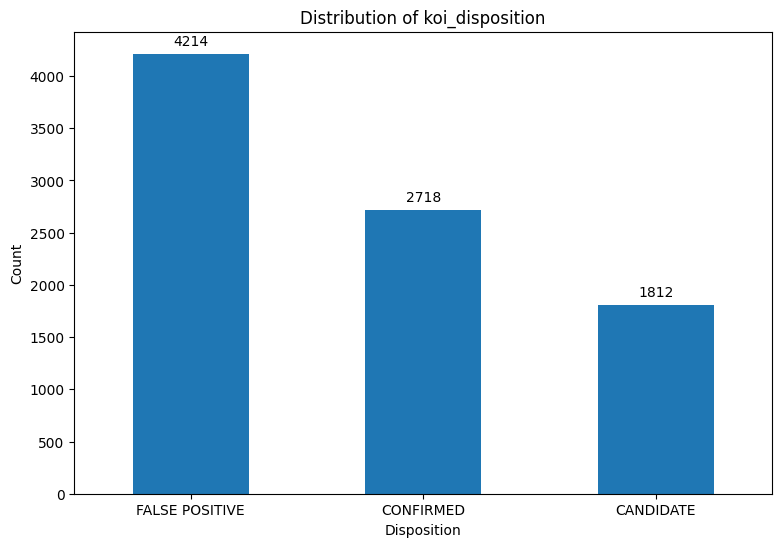

In [128]:
# Get counts
counts = keplar_df_cleaned["koi_disposition"].value_counts()

# Plot
ax = counts.plot(kind="bar", figsize=(9,6))
plt.xlabel("Disposition")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.title("Distribution of koi_disposition")

# Add values on top of bars
for i, v in enumerate(counts):
    ax.text(i, v + 50, str(v), ha="center", va="bottom")

plt.show()

In [129]:
keplar_df_cleaned

,koi_disposition,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,...,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag,target
0,CONFIRMED,0,0,0,0,9.488036,2.775000e-05,-2.775000e-05,170.538750,0.002160,...,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347,1
1,CONFIRMED,0,0,0,0,54.418383,2.479000e-04,-2.479000e-04,162.513840,0.003520,...,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347,1
2,CANDIDATE,0,0,0,0,19.899140,1.494000e-05,-1.494000e-05,175.850252,0.000581,...,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436,0
3,FALSE POSITIVE,0,1,0,0,1.736952,2.630000e-07,-2.630000e-07,170.307565,0.000115,...,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597,2
4,CONFIRMED,0,0,0,0,2.525592,3.761000e-06,-3.761000e-06,171.595550,0.001130,...,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,FALSE POSITIVE,0,1,1,0,0.527699,1.160000e-07,-1.160000e-07,131.705093,0.000170,...,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082,2
9560,CANDIDATE,0,0,0,0,1.739849,1.780000e-05,-1.780000e-05,133.001270,0.007690,...,4.444,0.056,-0.224,1.031,0.341,-0.114,286.50937,47.163219,14.757,0
9561,FALSE POSITIVE,0,0,1,0,0.681402,2.434000e-06,-2.434000e-06,132.181750,0.002850,...,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385,2
9562,CANDIDATE,0,0,0,0,333.486169,4.235000e-03,-4.235000e-03,153.615010,0.005070,...,2.992,0.030,-0.027,7.824,0.223,-1.896,296.76288,47.145142,10.998,0


In [178]:
# Separate features and target
X = keplar_df_cleaned.drop(columns=["koi_disposition", "target"])
y = keplar_df_cleaned["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Initialize StandardScaler
scaler_keplar = StandardScaler()

# Fit on training data and transform both train and test
X_train_scaled = pd.DataFrame(
    scaler_keplar.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler_keplar.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [179]:
import pandas as pd
import numpy as np
from sklearn.model_selection import ParameterGrid, cross_val_predict
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.base import clone

# -----------------------------
# Define models + parameter grids
# -----------------------------
models = {
    "RandomForest": (
        RandomForestClassifier(random_state=42),
        {
            "n_estimators": [100, 200],
            "max_depth": [None, 10],
            "min_samples_split": [2, 5],
        },
    ),
    "XGBoost": (
        XGBClassifier(eval_metric="mlogloss", random_state=42),
        {
            "n_estimators": [100, 200],
            "max_depth": [3, 5],
            "learning_rate": [0.05, 0.1],
            "subsample": [0.8, 1.0],
        },
    ),
    "GradientBoosting": (
        GradientBoostingClassifier(random_state=42),
        {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5],
        },
    ),
    "LightGBM": (
        LGBMClassifier(random_state=42, verbose=-1),
        {
            "n_estimators": [100, 200],
            "num_leaves": [31, 63],
            "learning_rate": [0.05, 0.1],
        },
    ),
    "MLP": (
        MLPClassifier(max_iter=1000, random_state=42),
        {
            "hidden_layer_sizes": [(50,), (100,), (50, 50)],
            "activation": ["relu", "tanh"],
            "learning_rate_init": [0.001, 0.01],
        },
    ),
}

# -----------------------------
# Train + evaluate with CV
# -----------------------------
def train_with_cv(model, param_grid, X, y, cv=5):
    results = []
    models_dict = {}

    for params in ParameterGrid(param_grid):
        clf = clone(model)
        clf.set_params(**params)

        # cross-validated predictions
        y_pred = cross_val_predict(clf, X, y, cv=cv, n_jobs=-1)

        # classification report
        report_dict = classification_report(y, y_pred, output_dict=True, zero_division=0)
        report_df = pd.DataFrame(report_dict).T

        # fit on full train for later usage
        clf.fit(X, y)

        key = ", ".join(f"{k}={v}" for k, v in params.items())
        models_dict[key] = {"model": clf, "cv_report": report_df}

        results.append({
            "params": params,
            "accuracy": report_dict["accuracy"],
            "f1_weighted": report_dict["weighted avg"]["f1-score"],
            "f1_macro": report_dict["macro avg"]["f1-score"],
        })

    return models_dict, pd.DataFrame(results)

In [180]:
# -----------------------------
# Run CV for all models for keplar dataset
# -----------------------------
all_models = {}
all_results = {}

for name, (estimator, grid) in models.items():
    print(f"Training {name} ...")
    model_dict, results_df = train_with_cv(estimator, grid, X_train_scaled, y_train, cv=5)
    all_models[name] = model_dict
    all_results[name] = results_df


Training RandomForest ...
Training XGBoost ...
Training GradientBoosting ...
Training LightGBM ...
Training MLP ...


d:\Documents\Assignment files\4th semester\A World Away\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


How to access a model from all_models

In [181]:
all_models['XGBoost']['learning_rate=0.1, max_depth=3, n_estimators=200, subsample=1.0']['model'].predict(X_test_scaled.iloc[0:5])

array([2, 2, 0, 2, 1])

In [182]:
X_test_scaled.iloc[0]

koi_fpflag_nt       -0.035165
koi_fpflag_ss        1.769102
koi_fpflag_co        1.994868
koi_fpflag_ec       -0.371946
koi_period          -0.452493
koi_period_err1     -0.245637
koi_period_err2      0.245637
koi_time0bk         -0.473343
koi_time0bk_err1     0.020932
koi_time0bk_err2    -0.020932
koi_impact          -0.188827
koi_impact_err1     -0.167492
koi_impact_err2      0.182957
koi_duration        -0.472099
koi_duration_err1   -0.106665
koi_duration_err2    0.106665
koi_depth           -0.290764
koi_depth_err1      -0.026018
koi_depth_err2       0.026018
koi_prad            -0.033277
koi_prad_err1       -0.043086
koi_prad_err2        0.028427
koi_teq              0.409883
koi_insol           -0.046745
koi_insol_err1      -0.062597
koi_insol_err2       0.039355
koi_model_snr       -0.322361
koi_tce_plnt_num    -0.367454
koi_steff           -0.373528
koi_steff_err1       0.423019
koi_steff_err2       0.200699
koi_slogg           -0.256508
koi_slogg_err1       1.213503
koi_slogg_

In [152]:
all_results['LightGBM']

,params,accuracy,f1_weighted,f1_macro
0,"{'learning_rate': 0.05, 'n_estimators': 100, '...",0.932144,0.931917,0.910529
1,"{'learning_rate': 0.05, 'n_estimators': 100, '...",0.933211,0.932921,0.911786
2,"{'learning_rate': 0.05, 'n_estimators': 200, '...",0.931839,0.931562,0.910096
3,"{'learning_rate': 0.05, 'n_estimators': 200, '...",0.935346,0.935079,0.914726
4,"{'learning_rate': 0.1, 'n_estimators': 100, 'n...",0.932449,0.932184,0.910933
5,"{'learning_rate': 0.1, 'n_estimators': 100, 'n...",0.933364,0.933129,0.912178
6,"{'learning_rate': 0.1, 'n_estimators': 200, 'n...",0.933974,0.933674,0.912813
7,"{'learning_rate': 0.1, 'n_estimators': 200, 'n...",0.933974,0.933738,0.912853


In [183]:
# -----------------------------
# Pick best params per model + retrain on full train + test on X_test_scaled
# -----------------------------
from sklearn.metrics import accuracy_score

final_summary = []
test_reports = {}

for name, df in all_results.items():
    # best by accuracy
    top_row = df.sort_values("accuracy", ascending=False).iloc[0]
    best_params = top_row["params"]

    # get trained model
    key = ", ".join(f"{k}={v}" for k, v in best_params.items())
    best_model = all_models[name][key]["model"]

    # evaluate on test
    y_pred_test = best_model.predict(X_test_scaled)
    test_report = classification_report(y_test, y_pred_test, output_dict=True, zero_division=0)
    test_reports[name] = pd.DataFrame(test_report).T

    final_summary.append({
        "model_name": name,
        "best_params": best_params,
        "cv_accuracy": top_row["accuracy"],
        "test_accuracy": test_report["accuracy"]
    })

final_summary_df = pd.DataFrame(final_summary).sort_values("test_accuracy", ascending=False).reset_index(drop=True)

# -----------------------------
# Results
# -----------------------------
print("\nBest models summary:")
final_summary_df


Best models summary:


,model_name,best_params,cv_accuracy,test_accuracy
0,LightGBM,"{'learning_rate': 0.05, 'n_estimators': 200, '...",0.934126,0.935041
1,GradientBoosting,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",0.930772,0.931839
2,XGBoost,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.932296,0.930467
3,RandomForest,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.923910,0.924977
4,MLP,"{'activation': 'relu', 'hidden_layer_sizes': (...",0.909576,0.922690


In [184]:
final_summary_df['best_params'][0]

{'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 31}

In [185]:
print("\nXGBoost test report:")
test_reports["XGBoost"]


XGBoost test report:


,precision,recall,f1-score,support
0,0.860849,0.805740,0.832383,453.000000
1,0.875177,0.908689,0.891618,679.000000
2,0.995270,0.998102,0.996684,1054.000000
accuracy,0.930467,0.930467,0.930467,0.930467
macro avg,0.910432,0.904177,0.906895,2186.000000
weighted avg,0.930112,0.930467,0.930002,2186.000000


### **TOI data**

In [65]:
toi_df = pd.read_csv("TOI_data.csv", comment="#")
toi_df

,toi,tid,tfopwg_disp,rastr,ra,decstr,dec,st_pmra,st_pmraerr1,st_pmraerr2,...,st_logg,st_loggerr1,st_loggerr2,st_logglim,st_rad,st_raderr1,st_raderr2,st_radlim,toi_created,rowupdate
0,1000.01,50365310,FP,07h29m25.85s,112.357708,-12d41m45.46s,-12.695960,-5.964,0.085,-0.085,...,4.19,0.07,-0.07,0,2.169860,0.072573,-0.072573,0,2019-07-24 15:58:33,2024-09-09 10:08:01
1,1001.01,88863718,PC,08h10m19.31s,122.580465,-05d30m49.87s,-5.513852,-4.956,0.102,-0.102,...,4.03,0.09,-0.09,0,2.010000,0.090000,-0.090000,0,2019-07-24 15:58:33,2023-04-03 14:31:04
2,1002.01,124709665,FP,06h58m54.47s,104.726966,-10d34m49.64s,-10.580455,-1.462,0.206,-0.206,...,NaN,NaN,NaN,0,5.730000,NaN,NaN,0,2019-07-24 15:58:33,2022-07-11 16:02:02
3,1003.01,106997505,FP,07h22m14.39s,110.559945,-25d12m25.26s,-25.207017,-0.939,0.041,-0.041,...,4.15,1.64,-1.64,0,NaN,NaN,NaN,0,2019-07-24 15:58:33,2022-02-23 10:10:02
4,1004.01,238597883,FP,08h08m42.77s,122.178195,-48d48m10.12s,-48.802811,-4.496,0.069,-0.069,...,4.14,0.07,-0.07,0,2.150000,0.060000,-0.060000,0,2019-07-24 15:58:33,2024-09-09 10:08:01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7694,995.01,317951248,FP,07h23m14.75s,110.811443,+05d33m46.26s,5.562850,2.061,0.405,-0.405,...,NaN,NaN,NaN,0,NaN,NaN,NaN,0,2019-07-24 15:58:33,2021-10-29 12:59:15
7695,996.01,142918609,FP,07h57m23.99s,119.349948,-19d30m57.65s,-19.516015,-3.900,0.848,-0.848,...,NaN,NaN,NaN,0,2.050000,NaN,NaN,0,2019-07-24 15:58:33,2021-10-29 12:59:15
7696,997.01,341729521,FP,08h05m16.69s,121.319521,-59d34m47.27s,-59.579798,-44.770,0.044,-0.044,...,4.52,0.08,-0.08,0,0.926261,0.045789,-0.045789,0,2019-07-24 15:58:33,2024-09-09 10:08:01
7697,998.01,54390047,FP,07h53m16.69s,118.319555,-14d13m07.76s,-14.218823,-1.706,0.069,-0.069,...,4.01,0.07,-0.07,0,2.349860,0.091578,-0.091578,0,2019-07-24 15:58:33,2024-09-09 10:08:01


In [66]:
toi_df.dtypes[toi_df.dtypes == "object"]

tfopwg_disp    object
rastr          object
decstr         object
toi_created    object
rowupdate      object
dtype: object

In [67]:
toi_df_cleaned = toi_df.drop(columns = ['rastr', 'decstr','toi_created','rowupdate'])
toi_df_cleaned.dtypes[toi_df_cleaned.dtypes == "object"]

tfopwg_disp    object
dtype: object

In [68]:
null_counts = toi_df_cleaned.isnull().sum()
temp = null_counts.value_counts().sort_index()
print(temp)

0       21
6        2
11       2
13       2
107      1
131      2
134      8
161      1
176      1
215      1
311      1
474      2
506      1
507      1
707      2
856      1
1623     2
1962     2
2270     2
7699     6
Name: count, dtype: int64


In [69]:
null_counts_toi = toi_df_cleaned.isnull().sum()
print("Null counts for each column:\n", null_counts_toi)

print("\nNull counts and the columns with those counts:")
for count in sorted(null_counts_toi.unique()): 
    if count == 0:
        continue
    columns_with_count = null_counts_toi[null_counts_toi == count].index.tolist()
    print(f"{count}: {columns_with_count}")

Null counts for each column:
 toi               0
tid               0
tfopwg_disp       0
ra                0
dec               0
               ... 
st_logglim        0
st_rad          507
st_raderr1     1962
st_raderr2     1962
st_radlim         0
Length: 61, dtype: int64

Null counts and the columns with those counts:
6: ['pl_trandeperr1', 'pl_trandeperr2']
11: ['pl_tranmiderr1', 'pl_tranmiderr2']
13: ['pl_trandurherr1', 'pl_trandurherr2']
107: ['pl_orbper']
131: ['pl_orbpererr1', 'pl_orbpererr2']
134: ['st_pmra', 'st_pmraerr1', 'st_pmraerr2', 'st_pmralim', 'st_pmdec', 'st_pmdecerr1', 'st_pmdecerr2', 'st_pmdeclim']
161: ['st_teff']
176: ['pl_insol']
215: ['st_dist']
311: ['pl_eqt']
474: ['st_tefferr1', 'st_tefferr2']
506: ['pl_rade']
507: ['st_rad']
707: ['st_disterr1', 'st_disterr2']
856: ['st_logg']
1623: ['pl_radeerr1', 'pl_radeerr2']
1962: ['st_raderr1', 'st_raderr2']
2270: ['st_loggerr1', 'st_loggerr2']
7699: ['pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqterr1', 'pl_eqt

In [99]:
cols_to_drop = list(null_counts_toi[null_counts_toi > 1000].index)

cols_to_drop.extend(['toi','tid'])


toi_df_cleaned2 = toi_df_cleaned.drop(columns=cols_to_drop)

# Display the shape of the cleaned DataFrame to see the result
print(f"Original shape: {toi_df_cleaned.shape}")
print(f"Shape after dropping columns with more than 600 nulls: {toi_df_cleaned2.shape}")

toi_df_cleaned2

Original shape: (7699, 61)
Shape after dropping columns with more than 600 nulls: (7699, 47)


,tfopwg_disp,ra,dec,st_pmra,st_pmraerr1,st_pmraerr2,st_pmralim,st_pmdec,st_pmdecerr1,st_pmdecerr2,...,st_disterr2,st_distlim,st_teff,st_tefferr1,st_tefferr2,st_tefflim,st_logg,st_logglim,st_rad,st_radlim
0,FP,112.357708,-12.695960,-5.964,0.085,-0.085,0.0,-0.076,0.072,-0.072,...,-11.9515,0,10249.0,264.7,-264.7,0,4.19,0,2.169860,0
1,PC,122.580465,-5.513852,-4.956,0.102,-0.102,0.0,-15.555,0.072,-0.072,...,-5.9100,0,7070.0,126.4,-126.4,0,4.03,0,2.010000,0
2,FP,104.726966,-10.580455,-1.462,0.206,-0.206,0.0,-2.249,0.206,-0.206,...,-106.3330,0,8924.0,124.0,-124.0,0,NaN,0,5.730000,0
3,FP,110.559945,-25.207017,-0.939,0.041,-0.041,0.0,1.640,0.055,-0.055,...,-1899.5700,0,5388.5,567.0,-567.0,0,4.15,0,NaN,0
4,FP,122.178195,-48.802811,-4.496,0.069,-0.069,0.0,9.347,0.062,-0.062,...,-4.6175,0,9219.0,171.1,-171.1,0,4.14,0,2.150000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7694,FP,110.811443,5.562850,2.061,0.405,-0.405,0.0,-7.082,0.336,-0.336,...,-355.6340,0,4805.2,46.5,-46.5,0,NaN,0,NaN,0
7695,FP,119.349948,-19.516015,-3.900,0.848,-0.848,0.0,3.866,1.158,-1.158,...,NaN,0,8007.0,NaN,NaN,0,NaN,0,2.050000,0
7696,FP,121.319521,-59.579798,-44.770,0.044,-0.044,0.0,-2.616,0.036,-0.036,...,-0.2655,0,5786.0,132.9,-132.9,0,4.52,0,0.926261,0
7697,FP,118.319555,-14.218823,-1.706,0.069,-0.069,0.0,-1.714,0.061,-0.061,...,-11.1405,0,8322.0,130.7,-130.7,0,4.01,0,2.349860,0


In [103]:
toi_df_cleaned2 = toi_df_cleaned2.dropna()
toi_df_cleaned2

,tfopwg_disp,ra,dec,st_pmra,st_pmraerr1,st_pmraerr2,st_pmralim,st_pmdec,st_pmdecerr1,st_pmdecerr2,...,st_disterr2,st_distlim,st_teff,st_tefferr1,st_tefferr2,st_tefflim,st_logg,st_logglim,st_rad,st_radlim
0,FP,112.357708,-12.695960,-5.964,0.085,-0.085,0.0,-0.076,0.072,-0.072,...,-11.9515,0,10249.0,264.7,-264.7,0,4.19,0,2.169860,0
1,PC,122.580465,-5.513852,-4.956,0.102,-0.102,0.0,-15.555,0.072,-0.072,...,-5.9100,0,7070.0,126.4,-126.4,0,4.03,0,2.010000,0
4,FP,122.178195,-48.802811,-4.496,0.069,-0.069,0.0,9.347,0.062,-0.062,...,-4.6175,0,9219.0,171.1,-171.1,0,4.14,0,2.150000,0
7,PC,112.752393,-4.463359,0.357,0.058,-0.058,0.0,3.399,0.045,-0.045,...,-3.0025,0,6596.0,139.2,-139.2,0,3.71,0,2.700000,0
12,PC,113.984761,-32.841999,145.102,0.046,-0.046,0.0,-134.901,0.052,-0.052,...,-0.0793,0,5413.7,132.8,-132.8,0,4.46,0,0.940000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7692,PC,113.960841,-15.499455,-9.483,0.058,-0.058,0.0,-4.963,0.050,-0.050,...,-5.4090,0,8035.0,150.8,-150.8,0,4.28,0,1.670000,0
7693,FP,115.046333,-9.084269,-7.229,0.089,-0.089,0.0,-2.482,0.079,-0.079,...,-19.1305,0,10393.0,222.8,-222.8,0,4.32,0,1.877390,0
7696,FP,121.319521,-59.579798,-44.770,0.044,-0.044,0.0,-2.616,0.036,-0.036,...,-0.2655,0,5786.0,132.9,-132.9,0,4.52,0,0.926261,0
7697,FP,118.319555,-14.218823,-1.706,0.069,-0.069,0.0,-1.714,0.061,-0.061,...,-11.1405,0,8322.0,130.7,-130.7,0,4.01,0,2.349860,0


In [105]:
toi_df_cleaned2['tfopwg_disp'].unique()

array(['FP', 'PC', 'APC', 'KP', 'CP', 'FA'], dtype=object)

In [109]:
import pandas as pd

# mapping dictionary
class_map = {
    "CP": "Confirmed",
    "KP": "Confirmed",
    "PC": "Candidate",
    "APC": "Candidate",
    "FP": "False Positive",
    "FA": "False Positive"
}

# map dispositions to 3 clean classes
toi_df_cleaned2["final_class"] = toi_df_cleaned2["tfopwg_disp"].map(class_map)

# manual label encoding (no sklearn needed)
label_encoding = {
    "Confirmed": 1,
    "Candidate": 0,
    "False Positive": 2
}

toi_df_cleaned2["target"] = toi_df_cleaned2["final_class"].map(label_encoding)

# check distribution
print(toi_df_cleaned2[["final_class", "target"]].value_counts())
toi_df_cleaned2

final_class     target
Candidate       0         4297
Confirmed       1         1092
False Positive  2          975
Name: count, dtype: int64


,tfopwg_disp,ra,dec,st_pmra,st_pmraerr1,st_pmraerr2,st_pmralim,st_pmdec,st_pmdecerr1,st_pmdecerr2,...,st_teff,st_tefferr1,st_tefferr2,st_tefflim,st_logg,st_logglim,st_rad,st_radlim,final_class,target
0,FP,112.357708,-12.695960,-5.964,0.085,-0.085,0.0,-0.076,0.072,-0.072,...,10249.0,264.7,-264.7,0,4.19,0,2.169860,0,False Positive,2
1,PC,122.580465,-5.513852,-4.956,0.102,-0.102,0.0,-15.555,0.072,-0.072,...,7070.0,126.4,-126.4,0,4.03,0,2.010000,0,Candidate,0
4,FP,122.178195,-48.802811,-4.496,0.069,-0.069,0.0,9.347,0.062,-0.062,...,9219.0,171.1,-171.1,0,4.14,0,2.150000,0,False Positive,2
7,PC,112.752393,-4.463359,0.357,0.058,-0.058,0.0,3.399,0.045,-0.045,...,6596.0,139.2,-139.2,0,3.71,0,2.700000,0,Candidate,0
12,PC,113.984761,-32.841999,145.102,0.046,-0.046,0.0,-134.901,0.052,-0.052,...,5413.7,132.8,-132.8,0,4.46,0,0.940000,0,Candidate,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7692,PC,113.960841,-15.499455,-9.483,0.058,-0.058,0.0,-4.963,0.050,-0.050,...,8035.0,150.8,-150.8,0,4.28,0,1.670000,0,Candidate,0
7693,FP,115.046333,-9.084269,-7.229,0.089,-0.089,0.0,-2.482,0.079,-0.079,...,10393.0,222.8,-222.8,0,4.32,0,1.877390,0,False Positive,2
7696,FP,121.319521,-59.579798,-44.770,0.044,-0.044,0.0,-2.616,0.036,-0.036,...,5786.0,132.9,-132.9,0,4.52,0,0.926261,0,False Positive,2
7697,FP,118.319555,-14.218823,-1.706,0.069,-0.069,0.0,-1.714,0.061,-0.061,...,8322.0,130.7,-130.7,0,4.01,0,2.349860,0,False Positive,2


In [222]:
X_toi=toi_df_cleaned2.drop(columns=["tfopwg_disp","final_class","target"])
y_toi=toi_df_cleaned2["target"]

X_train_toi, X_test_toi, y_train_toi, y_test_toi = train_test_split(
    X_toi, y_toi, test_size=0.25, random_state=42, stratify=y_toi
)


# Initialize StandardScaler
scaler_toi = StandardScaler()

# Fit on training data and transform both train and test
X_train_toi_scaled = pd.DataFrame(
    scaler_toi.fit_transform(X_train_toi),
    columns=X_train_toi.columns,
    index=X_train_toi.index
)

X_test_toi_scaled = pd.DataFrame(
    scaler_toi.transform(X_test_toi),
    columns=X_test_toi.columns,
    index=X_test_toi.index
)

In [187]:
# -----------------------------
# Run CV for all models
# -----------------------------
all_models_toi = {}
all_results_toi = {}

for name, (estimator, grid) in models.items():
    print(f"Training {name} ...")
    model_dict, results_df = train_with_cv(estimator, grid, X_train_toi_scaled, y_train_toi, cv=5)
    all_models_toi[name] = model_dict
    all_results_toi[name] = results_df


Training RandomForest ...
Training XGBoost ...
Training GradientBoosting ...
Training LightGBM ...
Training MLP ...


d:\Documents\Assignment files\4th semester\A World Away\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Documents\Assignment files\4th semester\A World Away\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [188]:
all_models_toi['LightGBM']['learning_rate=0.05, n_estimators=200, num_leaves=31']['model'].predict(X_test_toi_scaled.iloc[15:25])

array([0, 2, 0, 0, 2, 1, 0, 0, 0, 0])

In [191]:
all_results_toi['LightGBM']

,params,accuracy,f1_weighted,f1_macro
0,"{'learning_rate': 0.05, 'n_estimators': 100, '...",0.760737,0.741933,0.634840
1,"{'learning_rate': 0.05, 'n_estimators': 100, '...",0.764718,0.745857,0.639537
2,"{'learning_rate': 0.05, 'n_estimators': 200, '...",0.757176,0.738772,0.630430
3,"{'learning_rate': 0.05, 'n_estimators': 200, '...",0.768070,0.749231,0.643288
4,"{'learning_rate': 0.1, 'n_estimators': 100, 'n...",0.760109,0.741919,0.634370
5,"{'learning_rate': 0.1, 'n_estimators': 100, 'n...",0.764090,0.745630,0.638633
6,"{'learning_rate': 0.1, 'n_estimators': 200, 'n...",0.761576,0.743821,0.637685
7,"{'learning_rate': 0.1, 'n_estimators': 200, 'n...",0.767232,0.748566,0.641421


In [192]:
# -----------------------------
# Pick best params per model + retrain on full train + test on X_test_toi_scaled
# -----------------------------
from sklearn.metrics import accuracy_score

final_summary_toi = []
test_reports_toi = {}

for name, df in all_results_toi.items():
    # best by accuracy
    top_row = df.sort_values("accuracy", ascending=False).iloc[0]
    best_params = top_row["params"]

    # get trained model
    key = ", ".join(f"{k}={v}" for k, v in best_params.items())
    best_model = all_models_toi[name][key]["model"]

    # evaluate on test
    y_pred_test = best_model.predict(X_test_toi_scaled)
    test_report = classification_report(y_test_toi, y_pred_test, output_dict=True, zero_division=0)
    test_reports_toi[name] = pd.DataFrame(test_report).T

    final_summary_toi.append({
        "model_name": name,
        "best_params": best_params,
        "cv_accuracy": top_row["accuracy"],
        "test_accuracy": test_report["accuracy"]
    })

final_summary_toi_df = pd.DataFrame(final_summary_toi).sort_values("test_accuracy", ascending=False).reset_index(drop=True)

# -----------------------------
# Results
# -----------------------------
print("\nBest models summary:")
final_summary_toi_df


Best models summary:


,model_name,best_params,cv_accuracy,test_accuracy
0,GradientBoosting,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.762204,0.770585
1,LightGBM,"{'learning_rate': 0.05, 'n_estimators': 200, '...",0.768070,0.769327
2,XGBoost,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",0.761785,0.766813
3,RandomForest,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.745653,0.755500
4,MLP,"{'activation': 'relu', 'hidden_layer_sizes': (...",0.716950,0.727844


### **K2 Data**

In [193]:
k2_df = pd.read_csv("k2_data.csv", comment="#")
k2_df

,pl_name,hostname,default_flag,disposition,disp_refname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,BD+20 594 b,BD+20 594,0,CONFIRMED,Espinoza et al. 2016,1.0,1.0,Transit,2016.0,K2,...,-0.012,9.368,0.018,-0.018,10.86440,0.000249,-0.000249,2018-04-25,2018-03,2018-02-15
1,BD+20 594 b,BD+20 594,0,CONFIRMED,Espinoza et al. 2016,1.0,1.0,Transit,2016.0,K2,...,-0.012,9.368,0.018,-0.018,10.86440,0.000249,-0.000249,2018-04-25,2016-10,2016-07-28
2,BD+20 594 b,BD+20 594,1,CONFIRMED,Espinoza et al. 2016,1.0,1.0,Transit,2016.0,K2,...,-0.012,9.368,0.018,-0.018,10.86440,0.000249,-0.000249,2018-04-25,2017-03,2018-04-26
3,EPIC 201111557.01,EPIC 201111557,1,CANDIDATE,Livingston et al. 2018,1.0,0.0,Transit,2018.0,K2,...,-0.046,9.220,0.019,-0.019,11.39950,0.001307,-0.001307,2018-08-02,2018-08,2018-08-02
4,EPIC 201111557.01,EPIC 201111557,0,CANDIDATE,Livingston et al. 2018,1.0,0.0,Transit,2018.0,K2,...,-0.046,9.220,0.019,-0.019,11.39950,0.001307,-0.001307,2018-02-15,2018-03,2018-02-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3999,WASP-85 A b,WASP-85 A,0,CONFIRMED,Mo&,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4000,Wolf 503 b,Wolf 503,1,CONFIRMED,Peterson et al. 2018,1.0,1.0,Transit,2018.0,K2,...,-0.030,7.617,0.023,-0.023,9.89816,0.000337,-0.000337,2022-05-23,2021-12,2022-05-23
4001,Wolf 503 b,Wolf 503,0,CONFIRMED,Peterson et al. 2018,1.0,1.0,Transit,2018.0,K2,...,-0.030,7.617,0.023,-0.023,9.89816,0.000337,-0.000337,2018-09-04,2018-11,2018-09-06
4002,Wolf 503 b,Wolf 503,0,CONFIRMED,Peterson et al. 2018,1.0,1.0,Transit,2018.0,K2,...,-0.030,7.617,0.023,-0.023,9.89816,0.000337,-0.000337,2023-04-17,2023-04,2023-04-17


In [199]:
obj_cols = k2_df.dtypes[k2_df.dtypes == "object"].index.tolist()
obj_cols

['pl_name',
 'hostname',
 'disposition',
 'disp_refname',
 'discoverymethod',
 'disc_facility',
 'soltype',
 'pl_refname',
 'pl_bmassprov',
 'st_refname',
 'st_spectype',
 'st_metratio',
 'sy_refname',
 'rastr',
 'decstr',
 'rowupdate',
 'pl_pubdate',
 'releasedate']

In [230]:
k2_df_cleaned = k2_df.drop(columns = ['pl_name','disc_year','hostname','disp_refname','discoverymethod','disc_facility','soltype', 'pl_refname', 'pl_bmassprov', 'st_refname', 'st_spectype', 'st_metratio', 'sy_refname', 'rastr', 'decstr', 'rowupdate', 'pl_pubdate', 'releasedate'])
k2_df_cleaned.dtypes

default_flag         int64
disposition         object
sy_snum            float64
sy_pnum            float64
pl_controv_flag    float64
                    ...   
sy_kmagerr1        float64
sy_kmagerr2        float64
sy_gaiamag         float64
sy_gaiamagerr1     float64
sy_gaiamagerr2     float64
Length: 76, dtype: object

In [231]:
null_counts_k2 = k2_df_cleaned.isnull().sum()
print("Null counts for each column:\n", null_counts_k2)

print("\nNull counts and the columns with those counts:")
for count in sorted(null_counts_k2.unique()):
    if count == 0:
        continue
    columns_with_count = null_counts_k2[null_counts_k2 == count].index.tolist()
    print(f"{count}: {columns_with_count}")

Null counts for each column:
 default_flag        0
disposition         0
sy_snum            17
sy_pnum            17
pl_controv_flag    17
                   ..
sy_kmagerr1        54
sy_kmagerr2        54
sy_gaiamag         79
sy_gaiamagerr1     79
sy_gaiamagerr2     79
Length: 76, dtype: int64

Null counts and the columns with those counts:
17: ['sy_snum', 'sy_pnum', 'pl_controv_flag']
23: ['ttv_flag', 'ra', 'dec']
46: ['sy_kmag']
54: ['sy_kmagerr1', 'sy_kmagerr2']
65: ['sy_vmag', 'sy_vmagerr1', 'sy_vmagerr2']
67: ['pl_orbper', 'pl_orbperlim']
79: ['sy_gaiamag', 'sy_gaiamagerr1', 'sy_gaiamagerr2']
148: ['st_rad', 'st_radlim', 'sy_dist']
279: ['sy_disterr1', 'sy_disterr2']
778: ['st_raderr1']
784: ['st_raderr2']
845: ['pl_rade', 'pl_radelim', 'pl_radj', 'pl_radjlim']
952: ['pl_orbpererr1', 'pl_orbpererr2']
1127: ['st_teff', 'st_tefflim']
1130: ['pl_radeerr1', 'pl_radeerr2', 'pl_radjerr1', 'pl_radjerr2']
1434: ['st_tefferr1']
1440: ['st_tefferr2']
1657: ['st_logg', 'st_logglim']
1870: 

In [232]:
cols_to_drop = list(null_counts_k2[null_counts_k2 > 800].index)

# cols_to_drop.extend(['toi','tid'])


k2_df_cleaned2 = k2_df_cleaned.drop(columns=cols_to_drop)

# Display the shape of the cleaned DataFrame to see the result
print(f"Original shape: {k2_df_cleaned.shape}")
print(f"Shape after dropping columns with more than 800 nulls: {k2_df_cleaned2.shape}")

k2_df_cleaned2

Original shape: (4004, 76)
Shape after dropping columns with more than 800 nulls: (4004, 26)


,default_flag,disposition,sy_snum,sy_pnum,pl_controv_flag,pl_orbper,pl_orbperlim,ttv_flag,st_rad,st_raderr1,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,0,CONFIRMED,1.0,1.0,0.0,41.688644,0.0,0.0,0.956122,0.098585,...,-1.2400,10.849,0.012,-0.012,9.368,0.018,-0.018,10.86440,0.000249,-0.000249
1,0,CONFIRMED,1.0,1.0,0.0,41.685500,0.0,0.0,0.928000,0.055000,...,-1.2400,10.849,0.012,-0.012,9.368,0.018,-0.018,10.86440,0.000249,-0.000249
2,1,CONFIRMED,1.0,1.0,0.0,41.685500,0.0,0.0,1.080000,0.060000,...,-1.2400,10.849,0.012,-0.012,9.368,0.018,-0.018,10.86440,0.000249,-0.000249
3,1,CANDIDATE,1.0,0.0,0.0,2.301830,0.0,0.0,0.762602,0.053651,...,-0.4598,11.727,0.046,-0.046,9.220,0.019,-0.019,11.39950,0.001307,-0.001307
4,0,CANDIDATE,1.0,0.0,0.0,2.302368,0.0,0.0,0.710995,0.018609,...,-0.4598,11.727,0.046,-0.046,9.220,0.019,-0.019,11.39950,0.001307,-0.001307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3999,0,CONFIRMED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4000,1,CONFIRMED,1.0,1.0,0.0,6.001270,0.0,0.0,0.689000,0.021000,...,-0.0961,10.270,0.030,-0.030,7.617,0.023,-0.023,9.89816,0.000337,-0.000337
4001,0,CONFIRMED,1.0,1.0,0.0,6.001180,0.0,0.0,0.690000,0.025000,...,-0.0961,10.270,0.030,-0.030,7.617,0.023,-0.023,9.89816,0.000337,-0.000337
4002,0,CONFIRMED,1.0,1.0,0.0,6.001270,0.0,0.0,0.689000,0.021000,...,-0.0961,10.270,0.030,-0.030,7.617,0.023,-0.023,9.89816,0.000337,-0.000337


In [233]:
k2_df_cleaned['disposition'].unique()

array(['CONFIRMED', 'CANDIDATE', 'FALSE POSITIVE', 'REFUTED'],
      dtype=object)

Total nulls after imputing data: 0

 disposition
CONFIRMED         2315
CANDIDATE         1374
FALSE POSITIVE     315
Name: count, dtype: int64


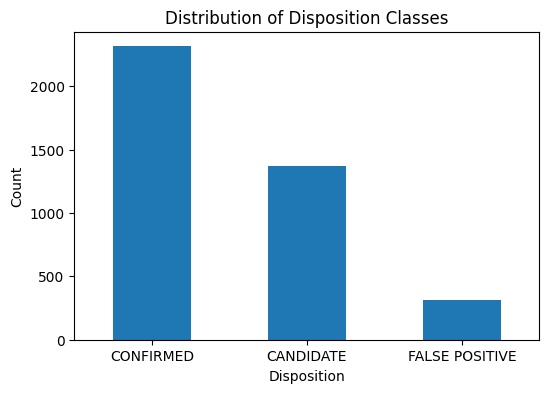

In [234]:
k2_df_cleaned2["disposition"] = k2_df_cleaned2["disposition"].replace(
    {"REFUTED": "FALSE POSITIVE",}
)


k2_df_cleaned2 = k2_df_cleaned2.groupby("disposition").transform(
    lambda x: x.fillna(x.mean())
).assign(disposition=k2_df_cleaned2["disposition"])

print("Total nulls after imputing data:",k2_df_cleaned2.isnull().sum().sum())

# Get counts per class
class_counts = k2_df_cleaned2["disposition"].value_counts()

# Print distribution
print("\n",class_counts)

# Plot as bar chart
class_counts.plot(kind="bar", figsize=(6,4), rot=0)
plt.title("Distribution of Disposition Classes")
plt.xlabel("Disposition")
plt.ylabel("Count")
plt.show()

In [235]:
k2_df_cleaned2["disposition"].unique()

array(['CONFIRMED', 'CANDIDATE', 'FALSE POSITIVE'], dtype=object)

In [236]:
label_encoding = {
    "CONFIRMED": 1,
    "CANDIDATE": 0,
    "FALSE POSITIVE": 2
}

k2_df_cleaned2["target"] = k2_df_cleaned2["disposition"].map(label_encoding)
k2_df_cleaned2

,default_flag,sy_snum,sy_pnum,pl_controv_flag,pl_orbper,pl_orbperlim,ttv_flag,st_rad,st_raderr1,st_raderr2,...,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,disposition,target
0,0,1.000000,1.000000,0.000000,41.688644,0.0,0.000000,0.956122,0.098585,-0.054675,...,0.012000,-0.012000,9.368000,0.018000,-0.018000,10.864400,0.000249,-0.000249,CONFIRMED,1
1,0,1.000000,1.000000,0.000000,41.685500,0.0,0.000000,0.928000,0.055000,-0.040000,...,0.012000,-0.012000,9.368000,0.018000,-0.018000,10.864400,0.000249,-0.000249,CONFIRMED,1
2,1,1.000000,1.000000,0.000000,41.685500,0.0,0.000000,1.080000,0.060000,-0.060000,...,0.012000,-0.012000,9.368000,0.018000,-0.018000,10.864400,0.000249,-0.000249,CONFIRMED,1
3,1,1.000000,0.000000,0.000000,2.301830,0.0,0.000000,0.762602,0.053651,-0.037585,...,0.046000,-0.046000,9.220000,0.019000,-0.019000,11.399500,0.001307,-0.001307,CANDIDATE,0
4,0,1.000000,0.000000,0.000000,2.302368,0.0,0.000000,0.710995,0.018609,-0.020398,...,0.046000,-0.046000,9.220000,0.019000,-0.019000,11.399500,0.001307,-0.001307,CANDIDATE,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3999,0,1.087903,1.935161,0.000435,21.947576,0.0,0.076353,0.909269,0.058853,-0.051246,...,0.092626,-0.092626,10.323815,0.022198,-0.022198,12.430787,0.000463,-0.000463,CONFIRMED,1
4000,1,1.000000,1.000000,0.000000,6.001270,0.0,0.000000,0.689000,0.021000,-0.020000,...,0.030000,-0.030000,7.617000,0.023000,-0.023000,9.898160,0.000337,-0.000337,CONFIRMED,1
4001,0,1.000000,1.000000,0.000000,6.001180,0.0,0.000000,0.690000,0.025000,-0.024000,...,0.030000,-0.030000,7.617000,0.023000,-0.023000,9.898160,0.000337,-0.000337,CONFIRMED,1
4002,0,1.000000,1.000000,0.000000,6.001270,0.0,0.000000,0.689000,0.021000,-0.020000,...,0.030000,-0.030000,7.617000,0.023000,-0.023000,9.898160,0.000337,-0.000337,CONFIRMED,1


In [237]:
from imblearn.over_sampling import SMOTE

# Separate features and target
X_k2 = k2_df_cleaned2.drop(columns=["disposition", "target"])
y_k2 = k2_df_cleaned2["target"]

# Train-test split (stratify to preserve distribution before SMOTE)
X_train_k2, X_test_k2, y_train_k2, y_test_k2 = train_test_split(
    X_k2, y_k2, test_size=0.25, random_state=42, stratify=y_k2
)

# Apply SMOTE only on training set
smote = SMOTE(random_state=42)
X_train_k2_res, y_train_k2_res = smote.fit_resample(X_train_k2, y_train_k2)

print("Before SMOTE:", y_train_k2.value_counts())
print("After SMOTE:", y_train_k2_res.value_counts())

Before SMOTE: target
1    1736
0    1031
2     236
Name: count, dtype: int64
After SMOTE: target
1    1736
0    1736
2    1736
Name: count, dtype: int64


In [242]:
# Initialize StandardScaler
scaler_k2 = StandardScaler()

X_train_k2_scaled = pd.DataFrame(
    scaler_k2.fit_transform(X_train_k2_res),
    columns=X_train_k2_res.columns
)

X_test_k2_scaled = pd.DataFrame(
    scaler_k2.transform(X_test_k2),
    columns=X_test_k2.columns
)

X_train_k2_scaled

,default_flag,sy_snum,sy_pnum,pl_controv_flag,pl_orbper,pl_orbperlim,ttv_flag,st_rad,st_raderr1,st_raderr2,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,0.983621,-0.15464,1.132837,-0.013943,-0.029386,0.028219,-0.160416,-0.362160,-0.194782,0.195490,...,0.188530,1.744803,6.095041,-6.095041,1.446114,0.665520,-0.665520,1.634684,-0.083813,0.083813
1,-1.016652,-0.15464,1.132837,-0.013943,-0.027753,0.028219,-0.160416,-0.106409,-0.217506,0.163270,...,0.302723,-1.143417,-0.571640,0.571640,-0.482577,-0.332911,0.332911,-0.836072,-0.448410,0.448410
2,-1.016652,-0.15464,1.132837,-0.013943,-0.032902,0.028219,-0.160416,-0.163390,-0.178550,0.178532,...,0.297603,-0.727117,-0.589838,0.589838,-0.467141,-0.332911,0.332911,-0.697532,-0.485406,0.485406
3,-1.016652,-0.15464,1.975328,-0.013943,-0.024472,0.028219,6.297164,-0.179733,-0.107132,0.103916,...,0.270912,-0.218856,-0.219804,0.219804,0.106063,0.083102,-0.083102,-0.197768,-0.359405,0.359405
4,0.983621,-0.15464,1.132837,-0.013943,-0.029449,0.028219,-0.160416,-0.229647,-0.211013,0.212448,...,0.253403,0.655044,-0.086349,0.086349,0.825200,-0.166506,0.166506,0.597345,-0.393720,0.393720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5203,0.983621,-0.15464,-0.552144,-0.013943,-0.032939,0.028219,-0.160416,0.075159,0.000448,0.004078,...,0.097055,2.542761,-0.217683,0.217683,3.093766,0.168775,-0.168775,2.838921,0.422952,-0.422952
5204,-1.016652,-0.15464,-0.552144,-0.013943,-0.032679,0.028219,-0.160416,0.181632,-0.050838,0.045102,...,0.231576,0.083457,-0.153076,0.153076,-0.072142,-0.582519,0.582519,0.023061,-0.483797,0.483797
5205,-1.016652,-0.15464,-0.552144,-0.013943,-0.023814,0.028219,-0.160416,0.002247,-0.002806,-0.003021,...,0.167478,-0.201574,-0.128188,0.128188,0.006997,-0.228871,0.228871,-0.250870,-0.456661,0.456661
5206,-1.016652,-0.15464,-0.552144,-0.013943,-0.032348,0.028219,-0.160416,0.393640,1.022290,-1.081012,...,0.173694,-1.616986,-0.741491,0.741491,-1.333614,-0.665721,0.665721,-1.577311,-0.014647,0.014647


In [250]:
# -----------------------------
# Run CV for all models
# -----------------------------
all_models_k2 = {}
all_results_k2 = {}

for name, (estimator, grid) in models.items():
    print(f"Training {name} ...")
    model_dict, results_df = train_with_cv(estimator, grid, X_train_k2_scaled, y_train_k2_res, cv=5)
    all_models_k2[name] = model_dict
    all_results_k2[name] = results_df


Training RandomForest ...
Training XGBoost ...
Training GradientBoosting ...
Training LightGBM ...
Training MLP ...


d:\Documents\Assignment files\4th semester\A World Away\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Documents\Assignment files\4th semester\A World Away\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [251]:
all_models_k2.keys()

dict_keys(['RandomForest', 'XGBoost', 'GradientBoosting', 'LightGBM', 'MLP'])

In [252]:
all_models_k2['LightGBM']['learning_rate=0.05, n_estimators=200, num_leaves=31']['model'].predict(X_test_k2_scaled.iloc[15:25])

array([0, 1, 2, 1, 1, 2, 1, 0, 0, 1])

In [253]:
# -----------------------------
# Pick best params per model + retrain on full train + test on X_test_k2_scaled
# -----------------------------
final_summary_k2 = []
test_reports_k2 = {}

for name, df in all_results_k2.items():
    # best by accuracy
    top_row = df.sort_values("accuracy", ascending=False).iloc[0]
    best_params = top_row["params"]

    # get trained model
    key = ", ".join(f"{k}={v}" for k, v in best_params.items())
    best_model = all_models_k2[name][key]["model"]

    # evaluate on test
    y_pred_test = best_model.predict(X_test_k2_scaled)
    test_report = classification_report(y_test_k2, y_pred_test, output_dict=True, zero_division=0)
    test_reports_k2[name] = pd.DataFrame(test_report).T

    final_summary_k2.append({
        "model_name": name,
        "best_params": best_params,
        "cv_accuracy": top_row["accuracy"],
        "test_accuracy": test_report["accuracy"]
    })

final_summary_k2_df = pd.DataFrame(final_summary_k2).sort_values("test_accuracy", ascending=False).reset_index(drop=True)

# -----------------------------
# Results
# -----------------------------
print("\nBest models summary:")
final_summary_k2_df


Best models summary:


,model_name,best_params,cv_accuracy,test_accuracy
0,XGBoost,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.974654,0.968032
1,GradientBoosting,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.973694,0.965035
2,LightGBM,"{'learning_rate': 0.1, 'n_estimators': 200, 'n...",0.980415,0.964036
3,RandomForest,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.971966,0.955045
4,MLP,"{'activation': 'tanh', 'hidden_layer_sizes': (...",0.959293,0.925075
